## Import Keras and Packages


Let's start by importing the keras libraries and the packages that we would need to build a neural network.


In [48]:
!pip install -q numpy==2.0.2
!pip install pandas==2.2.2
!pip install tensorflow_cpu==2.18.0
!pip install matplotlib==3.9.2
!pip install keras
!pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


...


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
import keras
import tensorflow as tf
from keras.models import Sequential     # To specifiy that we will have sequential neural network layers
from keras.layers import Dense          # Dense is a type of neural network layer called dense/fully connected
from keras.layers import Input          # only describes the input to the neual network
from keras.utils import to_categorical  # Coverts target classes into binary categories (one hot categories)
from sklearn.metrics import classification_report, f1_score

In [50]:
from keras.layers import Conv2D       # to add convolutional layers
from keras.layers import MaxPooling2D # to add pooling layers
from keras.layers import Flatten      # to flatten data for fully connected layers

In [51]:
#  import the Matplotlib scripting layer in order to view the images.
import numpy as np
import matplotlib.pyplot as plt

<a id='item42'></a>


In [52]:
# import data
from keras.datasets import cifar10

# load data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()



Let's normalize the pixel values to be between 0 and 1


In [53]:
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0


Next, we will convert the target variable into binary categories


In [54]:
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

num_classes = y_test.shape[1]

X_train: (50000, 32, 32, 3) y_train: (50000, 10)
X_test : (10000, 32, 32, 3) y_test : (10000, 10)


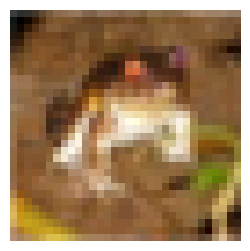

In [55]:
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

# Quick view (optional)
plt.figure(figsize=(3,3))
plt.imshow(X_train[0])
plt.axis("off")
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.20,
    horizontal_flip=True
)



# IMPORTANT: NO augmentation for test/validation (per instructions)
test_datagen = ImageDataGenerator()

batch_size = 128

train_generator = train_datagen.flow(X_train, y_train, batch_size=batch_size, shuffle=True)
test_generator  = test_datagen.flow(X_test, y_test, batch_size=batch_size, shuffle=False)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

def convolutional_model_3block_stronger(num_classes=10):
    wd = 5e-4  # weight decay (L2)

    model = Sequential()

    # Block 1
    model.add(Conv2D(64, (3,3), activation='relu', padding="same",
                     kernel_regularizer=l2(wd), input_shape=(32, 32, 3)))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3,3), activation='relu', padding="same",
                     kernel_regularizer=l2(wd)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.20))

    # Block 2
    model.add(Conv2D(128, (3,3), activation='relu', padding="same",
                     kernel_regularizer=l2(wd)))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3,3), activation='relu', padding="same",
                     kernel_regularizer=l2(wd)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.25))

    # Block 3
    model.add(Conv2D(256, (3,3), activation='relu', padding="same",
                     kernel_regularizer=l2(wd)))
    model.add(BatchNormalization())
    model.add(Conv2D(256, (3,3), activation='relu', padding="same",
                     kernel_regularizer=l2(wd)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.35))

    # BP Phase (classifier head)
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.50))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.40))
    model.add(Dense(num_classes, activation='softmax'))
    
    loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=loss_fn,
        metrics=['accuracy']
    )
    return model

In [64]:
# Build model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
model_3 = convolutional_model_3block_stronger(num_classes=num_classes)
model_3.summary()

# -----------------------------
# 5) Train + Evaluate
# -----------------------------
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

history = model_3.fit(
    train_generator,
    validation_data=test_generator,
    epochs=60,          # train longer for 90%+
    verbose=2,
    callbacks=callbacks
)

scores = model_3.evaluate(test_generator, verbose=0)
print("Accuracy:", scores[1], "\nError:", 100 - scores[1]*100)

C:\Users\Sadeen\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_41 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │       131,32

 Total params: 3,380,554 (12.90 MB)

 Trainable params: 3,378,762 (12.89 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/60
391/391 - 214s - 548ms/step - accuracy: 0.2860 - loss: 2.3683 - val_accuracy: 0.1591 - val_loss: 2.9503 - learning_rate: 1.0000e-03
Epoch 2/60
391/391 - 209s - 535ms/step - accuracy: 0.4370 - loss: 1.8811 - val_accuracy: 0.4686 - val_loss: 1.7686 - learning_rate: 1.0000e-03
Epoch 3/60
391/391 - 211s - 540ms/step - accuracy: 0.5230 - loss: 1.6405 - val_accuracy: 0.5867 - val_loss: 1.4649 - learning_rate: 1.0000e-03
Epoch 4/60
391/391 - 268s - 685ms/step - accuracy: 0.5927 - loss: 1.4584 - val_accuracy: 0.6417 - val_loss: 1.3106 - learning_rate: 1.0000e-03
Epoch 5/60
391/391 - 239s - 612ms/step - accuracy: 0.6305 - loss: 1.3575 - val_accuracy: 0.5834 - val_loss: 1.5628 - learning_rate: 1.0000e-03
Epoch 6/60
391/391 - 408s - 1s/step - accuracy: 0.6554 - loss: 1.3042 - val_accuracy: 0.6981 - val_loss: 1.2393 - learning_rate: 1.0000e-03
Epoch 7/60
391/391 - 210s - 537ms/step - accuracy: 0.6806 - loss: 1.2731 - val_accuracy: 0.7046 - val_loss: 1.2506 - learning_rate: 1.0000e-03
Ep

In [ ]:
def macro_f1(y_true_onehot, y_pred_probs, eps=1e-12):
    y_true = np.argmax(y_true_onehot, axis=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    num_classes = y_true_onehot.shape[1]

    f1s = []
    for c in range(num_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))

        precision = tp / (tp + fp + eps)
        recall    = tp / (tp + fn + eps)
        f1        = 2 * precision * recall / (precision + recall + eps)
        f1s.append(f1)

    return float(np.mean(f1s))

y_pred = model_3.predict(X_test, batch_size=256, verbose=0)
f1 = macro_f1(y_test, y_pred)
print("Block 3 CNN Macro-F1:", f1)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# IMPORTANT: NO augmentation for test/validation (per instructions)
test_datagen = ImageDataGenerator()

batch_size = 128

train_generator = train_datagen.flow(X_train, y_train, batch_size=batch_size, shuffle=True)
test_generator  = test_datagen.flow(X_test, y_test, batch_size=batch_size, shuffle=False)

------------------------------------------


<a id='item43'></a>


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

def convolutional_model_1block():
    model = Sequential()
    model.add(Conv2D(32, (3,3), activation='relu', padding="same", input_shape=(32, 32, 3)))
    model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
# build the model
model_1 = convolutional_model_1block()

# fit the model (augmentation only in training)
model_1.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20,
    verbose=2
)

# evaluate the model
scores_1 = model_1.evaluate(test_generator, verbose=0)
print("Block 1 Accuracy: {} \n Block 1 Error: {}".format(scores_1[1], 100 - scores_1[1]*100))



C:\Users\Sadeen\AppData\Roaming\Python\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
391/391 - 48s - 123ms/step - accuracy: 0.4093 - loss: 1.6642 - val_accuracy: 0.5144 - val_loss: 1.3758
Epoch 2/20
391/391 - 52s - 132ms/step - accuracy: 0.5039 - loss: 1.3986 - val_accuracy: 0.5397 - val_loss: 1.3101
Epoch 3/20
391/391 - 79s - 203ms/step - accuracy: 0.5381 - loss: 1.3044 - val_accuracy: 0.5740 - val_loss: 1.2173
Epoch 4/20
391/391 - 93s - 239ms/step - accuracy: 0.5529 - loss: 1.2592 - val_accuracy: 0.5964 - val_loss: 1.1245
Epoch 5/20
391/391 - 99s - 252ms/step - accuracy: 0.5687 - loss: 1.2200 - val_accuracy: 0.6060 - val_loss: 1.1304
Epoch 6/20
391/391 - 117s - 299ms/step - accuracy: 0.5770 - loss: 1.1917 - val_accuracy: 0.6058 - val_loss: 1.1363
Epoch 7/20
391/391 - 112s - 287ms/step - accuracy: 0.5870 - loss: 1.1677 - val_accuracy: 0.6254 - val_loss: 1.0600
Epoch 8/20
391/391 - 67s - 171ms/step - accuracy: 0.5981 - loss: 1.1388 - val_accuracy: 0.6315 - val_loss: 1.0336
Epoch 9/20
391/391 - 42s - 108ms/step - accuracy: 0.5990 - loss: 1.1326 - val_accuracy

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

def convolutional_model_2block():
    model = Sequential()
    model.add(Conv2D(32, (3,3), activation='relu', padding="same", input_shape=(32, 32, 3)))
    model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

    model.add(Conv2D(64, (3,3), activation='relu', padding="same"))
    model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [35]:
model_2 = convolutional_model_2block()

# fit the model
model_2.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20,
    verbose=2
)

# evaluate the model
scores_2 = model_2.evaluate(test_generator, verbose=0)
print("Block 2 Accuracy: {} \n Block 2 Error: {}".format(scores_2[1], 100 - scores_2[1]*100))

Epoch 1/20
391/391 - 78s - 200ms/step - accuracy: 0.4083 - loss: 1.6349 - val_accuracy: 0.5035 - val_loss: 1.3766
Epoch 2/20
391/391 - 52s - 134ms/step - accuracy: 0.5281 - loss: 1.3259 - val_accuracy: 0.6004 - val_loss: 1.1510
Epoch 3/20
391/391 - 29s - 75ms/step - accuracy: 0.5722 - loss: 1.2071 - val_accuracy: 0.6232 - val_loss: 1.0824
Epoch 4/20
391/391 - 30s - 76ms/step - accuracy: 0.6029 - loss: 1.1243 - val_accuracy: 0.6543 - val_loss: 0.9769
Epoch 5/20
391/391 - 29s - 75ms/step - accuracy: 0.6216 - loss: 1.0705 - val_accuracy: 0.6585 - val_loss: 0.9794
Epoch 6/20
391/391 - 30s - 76ms/step - accuracy: 0.6394 - loss: 1.0255 - val_accuracy: 0.6616 - val_loss: 0.9745
Epoch 7/20
391/391 - 28s - 73ms/step - accuracy: 0.6529 - loss: 0.9934 - val_accuracy: 0.6729 - val_loss: 0.9458
Epoch 8/20
391/391 - 40s - 101ms/step - accuracy: 0.6650 - loss: 0.9613 - val_accuracy: 0.6782 - val_loss: 0.9157
Epoch 9/20
391/391 - 31s - 78ms/step - accuracy: 0.6743 - loss: 0.9341 - val_accuracy: 0.7026

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

def convolutional_model_3block_improved():
    model = Sequential()

    # Block 1
    model.add(Conv2D(32, (3,3), activation='relu', padding="same", input_shape=(32, 32, 3)))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3,3), activation='relu', padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
    model.add(Dropout(0.25))

    # Block 2
    model.add(Conv2D(64, (3,3), activation='relu', padding="same"))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3,3), activation='relu', padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
    model.add(Dropout(0.30))

    # Block 3
    model.add(Conv2D(128, (3,3), activation='relu', padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
    model.add(Dropout(0.40))

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.50))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]


In [40]:
# build the model
model_3 = convolutional_model_3block_improved()

# fit the model
model_3.fit(
    train_generator,
    validation_data=test_generator,
    epochs=50,
    verbose=2,
    callbacks=callbacks
)

# evaluate the model
scores_3 = model_3.evaluate(test_generator, verbose=0)
print("Block 3 Accuracy: {} \n Block 3 Error: {}".format(scores_3[1], 100 - scores_3[1]*100))

Epoch 1/50
391/391 - 68s - 174ms/step - accuracy: 0.3307 - loss: 1.8546 - val_accuracy: 0.2539 - val_loss: 3.0777 - learning_rate: 1.0000e-03
Epoch 2/50
391/391 - 61s - 157ms/step - accuracy: 0.4626 - loss: 1.4829 - val_accuracy: 0.5448 - val_loss: 1.3015 - learning_rate: 1.0000e-03
Epoch 3/50
391/391 - 62s - 157ms/step - accuracy: 0.5320 - loss: 1.3035 - val_accuracy: 0.5800 - val_loss: 1.2613 - learning_rate: 1.0000e-03
Epoch 4/50
391/391 - 61s - 155ms/step - accuracy: 0.5816 - loss: 1.1852 - val_accuracy: 0.5057 - val_loss: 1.6247 - learning_rate: 1.0000e-03
Epoch 5/50
391/391 - 61s - 156ms/step - accuracy: 0.6225 - loss: 1.0836 - val_accuracy: 0.6266 - val_loss: 1.1283 - learning_rate: 1.0000e-03
Epoch 6/50
391/391 - 61s - 156ms/step - accuracy: 0.6446 - loss: 1.0256 - val_accuracy: 0.6440 - val_loss: 1.0790 - learning_rate: 1.0000e-03
Epoch 7/50
391/391 - 61s - 157ms/step - accuracy: 0.6626 - loss: 0.9774 - val_accuracy: 0.6840 - val_loss: 0.9486 - learning_rate: 1.0000e-03
Epoch 

In [ ]:
def macro_f1(y_true_onehot, y_pred_probs, eps=1e-12):
    y_true = np.argmax(y_true_onehot, axis=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    num_classes = y_true_onehot.shape[1]

    f1s = []
    for c in range(num_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))

        precision = tp / (tp + fp + eps)
        recall    = tp / (tp + fn + eps)
        f1        = 2 * precision * recall / (precision + recall + eps)
        f1s.append(f1)

    return float(np.mean(f1s))

y_pred = model_3.predict(X_test, batch_size=256, verbose=0)
f1 = macro_f1(y_test, y_pred)
print("Block 3 CNN Macro-F1:", f1)


Block 3 CNN Macro-F1: 0.8059846162560358


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

def convolutional_model_3block_stronger(num_classes=10):
    model = Sequential()

    # Block 1
    model.add(Conv2D(64, (3,3), activation='relu', padding="same", input_shape=(32, 32, 3)))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3,3), activation='relu', padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.25))

    # Block 2
    model.add(Conv2D(128, (3,3), activation='relu', padding="same"))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3,3), activation='relu', padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.30))

    # Block 3
    model.add(Conv2D(256, (3,3), activation='relu', padding="same"))
    model.add(BatchNormalization())
    model.add(Conv2D(256, (3,3), activation='relu', padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.40))
    
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.50))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.40))
    model.add(Dense(num_classes, activation='softmax'))


    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [46]:
model_3 = convolutional_model_3block_stronger(num_classes=num_classes)

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history = model_3.fit(
    train_generator,
    validation_data=test_generator,
    epochs=80,
    verbose=2,
    callbacks=callbacks
)

scores = model_3.evaluate(test_generator, verbose=0)
print("Accuracy:", scores[1], "\nError:", 100 - scores[1]*100)



Epoch 1/80
391/391 - 218s - 557ms/step - accuracy: 0.3179 - loss: 1.9412 - val_accuracy: 0.1564 - val_loss: 2.4453 - learning_rate: 1.0000e-03
Epoch 2/80
391/391 - 247s - 631ms/step - accuracy: 0.4760 - loss: 1.4514 - val_accuracy: 0.5266 - val_loss: 1.3414 - learning_rate: 1.0000e-03
Epoch 3/80
391/391 - 325s - 831ms/step - accuracy: 0.5756 - loss: 1.2200 - val_accuracy: 0.6513 - val_loss: 1.0307 - learning_rate: 1.0000e-03
Epoch 4/80
391/391 - 206s - 527ms/step - accuracy: 0.6320 - loss: 1.0734 - val_accuracy: 0.6277 - val_loss: 1.0481 - learning_rate: 1.0000e-03
Epoch 5/80
391/391 - 373s - 954ms/step - accuracy: 0.6699 - loss: 0.9625 - val_accuracy: 0.6654 - val_loss: 0.9320 - learning_rate: 1.0000e-03
Epoch 6/80
391/391 - 375s - 959ms/step - accuracy: 0.7022 - loss: 0.8778 - val_accuracy: 0.7311 - val_loss: 0.7979 - learning_rate: 1.0000e-03
Epoch 7/80
391/391 - 1316s - 3s/step - accuracy: 0.7262 - loss: 0.8275 - val_accuracy: 0.7181 - val_loss: 0.8398 - learning_rate: 1.0000e-03
E